# Prediksi harga jual emas

## Load Data

In [394]:
#import library
import pandas as pd
 
# Load data
raw_df = pd.read_csv('https://raw.githubusercontent.com/atsugaa/psd/refs/heads/main/data.csv')
pd.options.display.float_format = '{:.0f}'.format
raw_df

,date,sell,buy
0,2024-10-11,1432610,1396794
1,2024-10-10,1424822,1389201
2,2024-10-09,1432749,1396930
3,2024-10-08,1432889,1397066
4,2024-10-07,1429635,1393894
...,...,...,...
1585,2019-10-18,703072,678464
1586,2019-10-17,704616,679954
1587,2019-10-16,703714,679084
1588,2019-10-15,707582,682816


## Plotting Data

In [395]:
df = raw_df[['date', 'sell']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

C:\Users\atsuga\AppData\Local\Temp\ipykernel_9872\336552456.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date


,sell
date,
2019-10-14,704093
2019-10-15,707582
2019-10-16,703714
2019-10-17,704616
2019-10-18,703072
...,...
2024-10-07,1429635
2024-10-08,1432889
2024-10-09,1432749


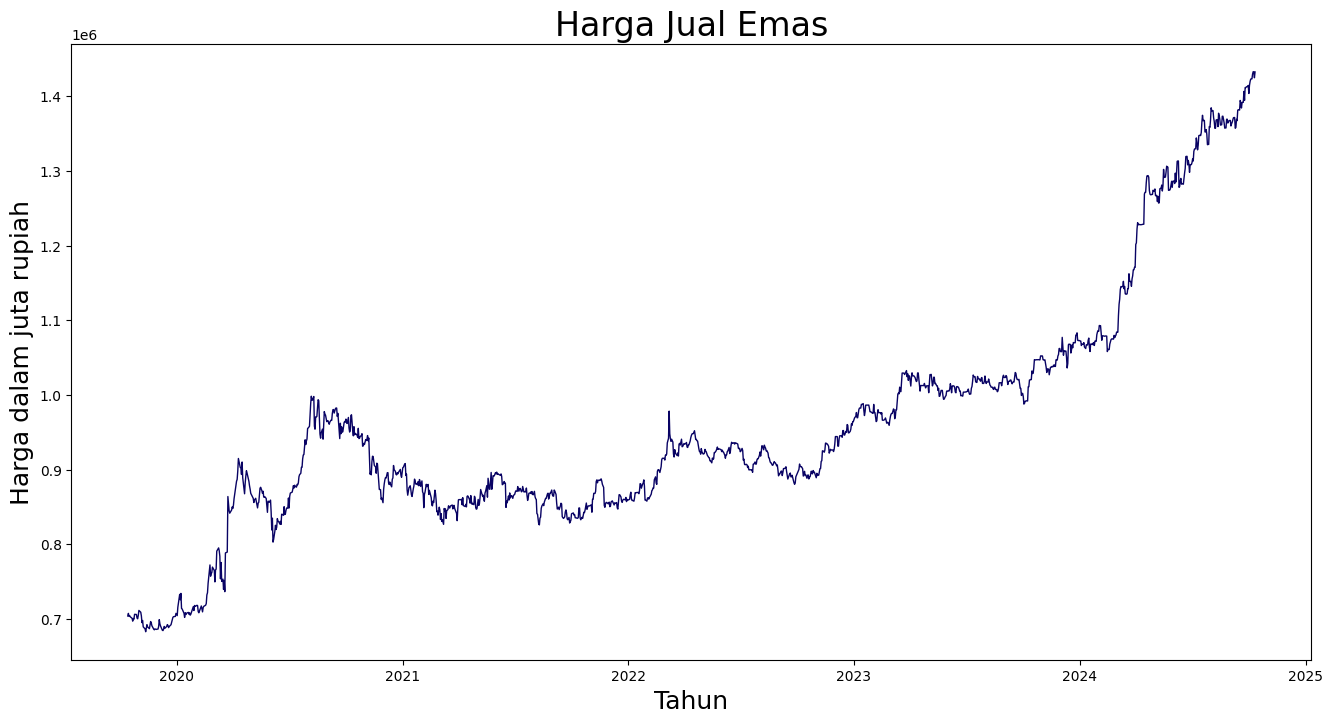

In [396]:
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("Harga Jual Emas", fontsize=24)
plt.ylabel('Harga dalam juta rupiah', fontsize=18)
plt.xlabel('Tahun', fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df['sell'], linewidth=1.0, dashes=False, ax=ax1)
plt.show()

## Preprocessing Data

### Normalisasi Data

In [397]:
def normalize(df):
    from sklearn.preprocessing import RobustScaler, MinMaxScaler

    np_data_unscaled = np.array(df)
    scaler = MinMaxScaler()
    np_data_scaled = scaler.fit_transform(np_data_unscaled)
    print(np_data_unscaled)
    normalized_df = pd.DataFrame(np_data_scaled, columns=df.columns, index=df.index)
    pd.set_option('display.float_format', '{:.4f}'.format)  # Menampilkan 4 desimal
    return normalized_df, scaler

normalized_df, scaler = normalize(df)
normalized_df

[[ 704093]
 [ 707582]
 [ 703714]
 ...
 [1432749]
 [1424822]
 [1432610]]


,sell
date,
2019-10-14,0.0281
2019-10-15,0.0327
2019-10-16,0.0276
2019-10-17,0.0288
2019-10-18,0.0267
...,...
2024-10-07,0.9957
2024-10-08,1.0000
2024-10-09,0.9998


### Sliding Window

In [398]:
def sliding_window(data, lag):
    series = data['sell']
    result = pd.DataFrame()
    for l in lag:
        result[f'sell-{l}'] = series.shift(l)

    result['sell'] = series[l:]
    result = result.dropna()
    result.index = series.index[l:]  # Mengatur index sesuai dengan nilai lag
    return result

windowed_data = sliding_window(normalized_df, [1, 2, 3])
windowed_data = windowed_data[['sell', 'sell-1', 'sell-2', 'sell-3']]
print(windowed_data)

             sell  sell-1  sell-2  sell-3
date                                     
2019-10-17 0.0288  0.0276  0.0327  0.0281
2019-10-18 0.0267  0.0288  0.0276  0.0327
2019-10-21 0.0239  0.0267  0.0288  0.0276
2019-10-22 0.0189  0.0239  0.0267  0.0288
2019-10-23 0.0236  0.0189  0.0239  0.0267
...           ...     ...     ...     ...
2024-10-07 0.9957  0.9873  0.9873  0.9868
2024-10-08 1.0000  0.9957  0.9873  0.9873
2024-10-09 0.9998  1.0000  0.9957  0.9873
2024-10-10 0.9892  0.9998  1.0000  0.9957
2024-10-11 0.9996  0.9892  0.9998  1.0000

[1587 rows x 4 columns]


### Splitting Data

In [399]:
def split_data(data, target, train_size):
    split_index = int(len(data) * train_size)

    x_train = data[:split_index]
    y_train = target[:split_index]
    x_test = data[split_index:]
    y_test = target[split_index:]

    return x_train, y_train, x_test, y_test

input_df = windowed_data[['sell-1', 'sell-2', 'sell-3']]
target_df = windowed_data[['sell']]

x_train, y_train, x_test, y_test = split_data(input_df, target_df, 0.8)

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1269, 3)
y_train shape: (1269, 1)
X_test shape: (318, 3)
y_test shape: (318, 1)


## Modelling

### Regresi Linear tanpa Ensemble Bagging

In [400]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [401]:
# Melakukan prediksi
y_pred = linear_model.predict(x_test)

# Menghitung error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Percentage Error (MAPE):", mape, " %")

Mean Squared Error (MSE): 0.00012521727152976203
Root Mean Squared Error (RMSE): 0.011190052347051914
Mean Absolute Percentage Error (MAPE): 0.010482371265015689  %


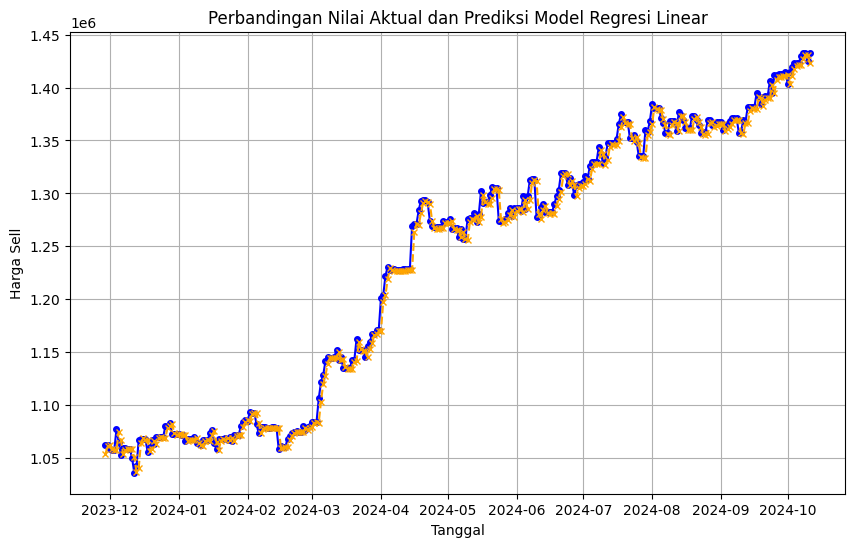

In [402]:
# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, scaler.inverse_transform(y_test.values.reshape(-1, 1)), label='Aktual', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, scaler.inverse_transform(y_pred.reshape(-1, 1)), label='Prediksi', color='orange', marker='x', linestyle='--', markersize=4)
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear')
plt.xlabel('Tanggal')
plt.ylabel('Harga Sell')
plt.grid()
plt.show()

In [403]:
last_row = windowed_data.iloc[-1][['sell-1', 'sell-2', 'sell-3']].values.reshape(1, -1)
predicted_value_normalized = linear_model.predict(last_row)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))

last_price = scaler.inverse_transform(normalized_df[['sell']].iloc[-1].values.reshape(-1, 1))
percentage_change = ((predicted_value[0][0] - last_price[0][0]) / last_price[0][0]) * 100

if percentage_change > 0:
    change_sign = '+'
else:
    change_sign = ''

print(f'Harga emas hari ini: {last_price[0][0]}')
print(f'Prediksi harga emas untuk hari esok: {predicted_value[0][0]} ({change_sign}{percentage_change:.2f}%)')

Harga emas hari ini: 1432610.0
Prediksi harga emas untuk hari esok: 1423490.2503133498 (-0.64%)


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Regresi Linear dengan Ensemble Bagging

In [404]:
from sklearn.ensemble import BaggingRegressor
base_model = LinearRegression()
bagging_model = BaggingRegressor(estimator=base_model, n_estimators=10, bootstrap=True)
bagging_model.fit(x_train, y_train)
y_pred = bagging_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape} %')

Mean Squared Error: 0.0001273975321659915
Root Mean Squared Error: 0.011287051526682754
Mean Absolute Percentage Error (MAPE): 0.010679093537928662 %


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:581: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


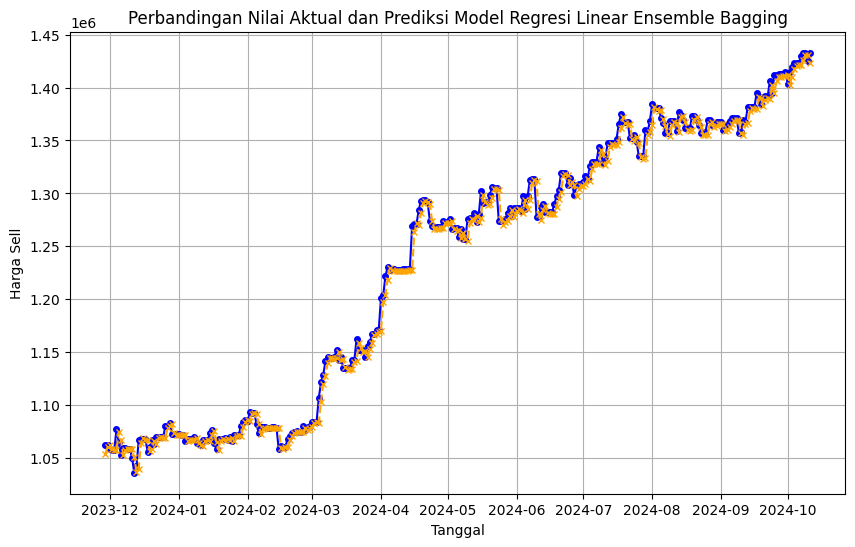

In [405]:
# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, scaler.inverse_transform(y_test.values.reshape(-1, 1)), label='Aktual', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, scaler.inverse_transform(y_pred.reshape(-1, 1)), label='Prediksi', color='orange', marker='x', linestyle='--', markersize=4)
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear Ensemble Bagging')
plt.xlabel('Tanggal')
plt.ylabel('Harga Sell')
plt.grid()
plt.show()

In [406]:
last_row = windowed_data.iloc[-1][['sell-1', 'sell-2', 'sell-3']].values.reshape(1, -1)
predicted_value_normalized = bagging_model.predict(last_row)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))
last_price = scaler.inverse_transform(normalized_df[['sell']].iloc[-1].values.reshape(-1, 1))
percentage_change = ((predicted_value[0][0] - last_price[0][0]) / last_price[0][0]) * 100
if percentage_change > 0:
    change_sign = '+'
else:
    change_sign = ''

print(f'Harga emas hari ini: {last_price[0][0]}')
print(f'Prediksi harga emas untuk hari esok: {predicted_value[0][0]} ({change_sign}{percentage_change:.2f}%)')

Harga emas hari ini: 1432610.0
Prediksi harga emas untuk hari esok: 1423168.626103751 (-0.66%)


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(


### Grid Search

In [407]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def grid_search(input_df, target_df, splits, estimators, bootstrap, max_samples):
    best_rmse = float('inf')
    best_params = None
    i = 0
    for split in splits:
        x_train, y_train, x_test, y_test = split_data(input_df, target_df, 0.8)
        for estimator in estimators:
            for bootstrap in bootstraps:
                for max_sample in max_samples:
                    base_model = LinearRegression()
                    bagging_model = BaggingRegressor(estimator=base_model, n_estimators=estimator, bootstrap=bootstrap, max_samples=max_sample)
                    bagging_model.fit(x_train, y_train.values.ravel())
                    y_pred = bagging_model.predict(x_test)
                    i+=1
                    current_rmse = rmse(y_test, y_pred)
                    #print(f'Model {i} split: {split}, estimator: {estimator}, bootstrap: {bootstrap}, max sample: {max_sample}, RMSE: {current_rmse}')
                    if current_rmse < best_rmse:
                        best_rmse = current_rmse
                        best_model = bagging_model
                        best_params = {'estimator': estimator, 'bootstrap': bootstrap, 'train_sample': split, 'max_sample': max_sample}
                    tf.keras.backend.clear_session()
    return best_params, best_rmse, best_model

# Parameter untuk Grid Search
splits = [0.7, 0.75, 0.8, 0.85, 0.9]
estimators = [10, 20, 50, 100]
bootstraps = [True, False]
max_samples = [0.8, 0.9, 1.0]

best_params, best_rmse, best_model = grid_search(input_df, target_df, splits, estimators, bootstraps, max_samples)

Dari 120 model, didapatkan model terbaik dengan parameter berikut

In [408]:
# Parameter terbaik
print(f'Best parameters: {best_params}')
print(f'Best RMSE: {best_rmse}')

Best parameters: {'estimator': 10, 'bootstrap': False, 'train_sample': 0.85, 'max_sample': 0.8}
Best RMSE: 0.011039280796414285


### Uji Coba

In [416]:
sell_1 = int(input("Harga emas hari ini: "))
sell_2 = int(input("Harga emas 1 hari sebelumnya: "))
sell_3 = int(input("Harga emas 2 hari sebelumnya: "))

#sell_1 = 1492738
#sell_2 = 1432846
#sell_3 = 1443278

last_row = np.array([
    scaler.transform([[sell_1]]).flatten()[0],
    scaler.transform([[sell_2]]).flatten()[0],
    scaler.transform([[sell_3]]).flatten()[0]
]).reshape(1, -1)
last_row_df = pd.DataFrame(last_row, columns=['sell-1', 'sell-2', 'sell-3'])
predicted_value_normalized = best_model.predict(last_row_df)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))
last_price = sell_1
percentage_change = ((predicted_value[0][0] - last_price) / last_price) * 100
change_sign = '+' if percentage_change > 0 else ''

formatted_predicted_value = f"{predicted_value[0][0]:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
formatted_last_price = f"{last_price:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f'Harga emas hari ini: Rp {formatted_last_price}')
print(f'Prediksi harga emas untuk hari esok: Rp {formatted_predicted_value} ({change_sign}{percentage_change:.2f}%)')

Harga emas hari ini:  1442587
Harga emas 1 hari sebelumnya:  1397535
Harga emas 2 hari sebelumnya:  1364368


Harga emas hari ini: Rp 1.442.587,00
Prediksi harga emas untuk hari esok: Rp 1.436.242,65 (-0.44%)
